In [2]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

pivot_nav = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change().dropna()

print(returns.shape)
returns.head()

(1149, 40)


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680
2022-01-10,-0.008639,0.006791,0.006277,0.011548,0.001251,0.000690,-0.001202,-0.000722,-0.011593,0.006360,...,-0.002583,0.000853,0.003057,-0.019536,0.024234,-0.011127,0.009372,0.001601,0.003650,0.001356


In [4]:
var95 = returns.quantile(0.05)

cvar95 = returns.apply(
    lambda x: x[x <= x.quantile(0.05)].mean()
)

var_cvar = pd.DataFrame({
    "VaR_95": var95,
    "CVaR_95": cvar95
})

print(var_cvar.head())

var_cvar.to_csv(
    "../reports/var_cvar_report.csv"
)

             VaR_95   CVaR_95
amfi_code                    
100016    -0.014364 -0.018060
100025    -0.003793 -0.004994
100033    -0.019034 -0.023456
101206    -0.013282 -0.017439
101207    -0.026021 -0.032459


In [5]:
import os

print(os.path.exists("../reports/var_cvar_report.csv"))

True


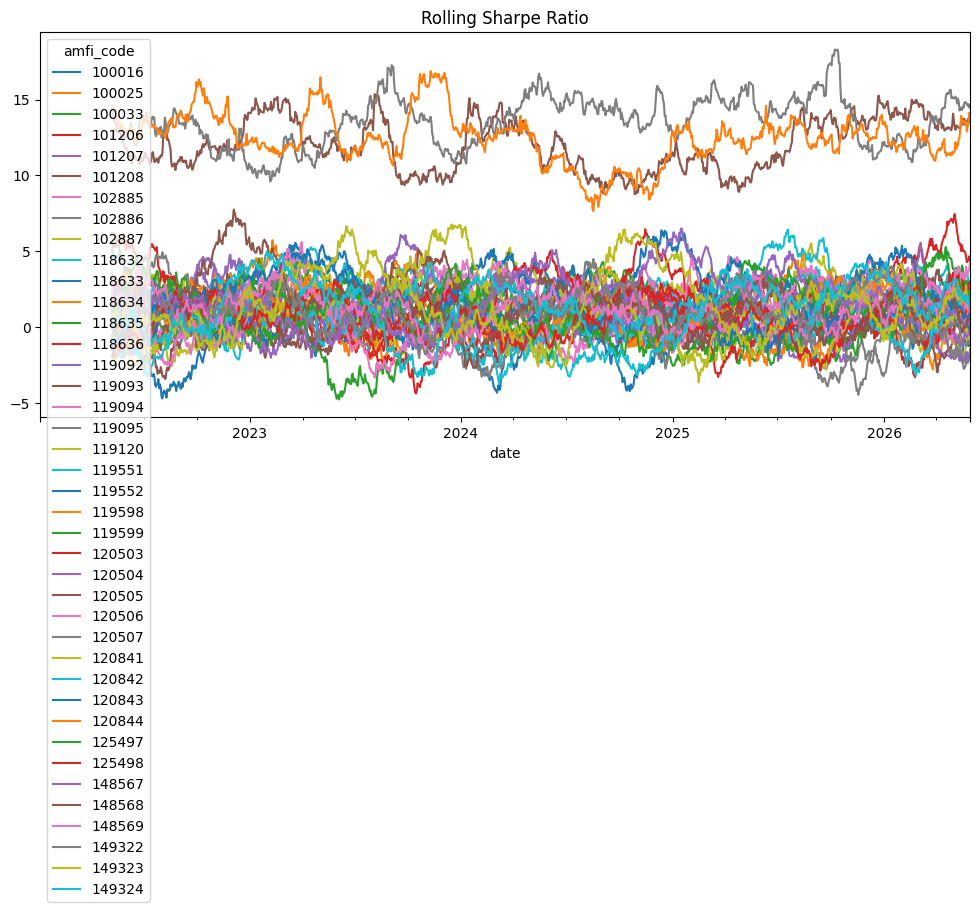

In [6]:
import matplotlib.pyplot as plt
import numpy as np

rolling_sharpe = (
    returns.rolling(90).mean()
    /
    returns.rolling(90).std()
) * np.sqrt(252)

rolling_sharpe.plot(
    figsize=(12,5)
)

plt.title("Rolling Sharpe Ratio")

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [8]:
import os

print(os.listdir("../reports"))

['alpha_beta.csv', 'category_inflow_heatmap.png', 'correlation_matrix.png', 'data_dictionary.md', 'folio_growth.png', 'max_drawdown.csv', 'rolling_sharpe_chart.png', 'sector_allocation_donut.png', 'sharpe_ratio.csv', 'sortino_ratio.csv', 'var_95.csv', 'var_cvar_report.csv']


In [9]:
import pandas as pd

sharpe = pd.read_csv("../reports/sharpe_ratio.csv")

print(sharpe.columns.tolist())
print(sharpe.head())

['amfi_code', 'sharpe_ratio']
   amfi_code  sharpe_ratio
0     100016     -0.098411
1     100025     -0.182996
2     100033      1.172910
3     101206      1.130177
4     101207      0.220806


In [10]:
drawdown = pd.read_csv("../reports/max_drawdown.csv")

print(drawdown.columns.tolist())
print(drawdown.head())

['amfi_code', 'max_drawdown']
   amfi_code  max_drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469


In [11]:
var95 = pd.read_csv("../reports/var_95.csv")

print(var95.columns.tolist())
print(var95.head())

['amfi_code', 'VaR_95']
   amfi_code    VaR_95
0     100016 -0.014364
1     100025 -0.003793
2     100033 -0.019034
3     101206 -0.013282
4     101207 -0.026021


In [12]:
import pandas as pd

sharpe = pd.read_csv("../reports/sharpe_ratio.csv")

print(sharpe.columns.tolist())
print(sharpe.head())

['amfi_code', 'sharpe_ratio']
   amfi_code  sharpe_ratio
0     100016     -0.098411
1     100025     -0.182996
2     100033      1.172910
3     101206      1.130177
4     101207      0.220806


In [13]:
import pandas as pd

drawdown = pd.read_csv("../reports/max_drawdown.csv")

print(drawdown.columns.tolist())
print(drawdown.head())

['amfi_code', 'max_drawdown']
   amfi_code  max_drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469


In [14]:
import pandas as pd

drawdown = pd.read_csv("../reports/max_drawdown.csv")

print(drawdown.columns.tolist())
print(drawdown.head())

['amfi_code', 'max_drawdown']
   amfi_code  max_drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469


In [15]:
import os

print(os.listdir("../reports"))

['alpha_beta.csv', 'category_inflow_heatmap.png', 'correlation_matrix.png', 'data_dictionary.md', 'folio_growth.png', 'max_drawdown.csv', 'rolling_sharpe_chart.png', 'sector_allocation_donut.png', 'sharpe_ratio.csv', 'sortino_ratio.csv', 'var_95.csv', 'var_cvar_report.csv']


In [16]:
import pandas as pd

drawdown = pd.read_csv("../reports/max_drawdown.csv")

print(drawdown.columns.tolist())
print(drawdown.head())

['amfi_code', 'max_drawdown']
   amfi_code  max_drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469


In [17]:
import pandas as pd

# Load files
sharpe = pd.read_csv("../reports/sharpe_ratio.csv")
drawdown = pd.read_csv("../reports/max_drawdown.csv")
var95 = pd.read_csv("../reports/var_95.csv")

# Merge all metrics
scorecard = sharpe.merge(
    drawdown,
    on="amfi_code"
).merge(
    var95,
    on="amfi_code"
)

# Rankings
scorecard["Sharpe_Rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["Drawdown_Rank"] = scorecard["max_drawdown"].rank(
    ascending=False
)

scorecard["VaR_Rank"] = scorecard["VaR_95"].rank(
    ascending=False
)

# Composite score
scorecard["Fund_Score"] = (
    scorecard["Sharpe_Rank"] * 0.50 +
    scorecard["Drawdown_Rank"] * 0.30 +
    scorecard["VaR_Rank"] * 0.20
)

# Best funds first
scorecard = scorecard.sort_values(
    "Fund_Score"
)

print(scorecard.head())

# Save
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

    amfi_code  sharpe_ratio  max_drawdown    VaR_95  Sharpe_Rank  \
27     120507      3.532698     -0.000977 -0.000222          1.0   
31     120844      2.833423     -0.001163 -0.000285          2.0   
5      101208      2.146301     -0.001622 -0.000269          3.0   
34     148567      1.553972     -0.112657 -0.013560          4.0   
19     119551      1.317425     -0.150124 -0.012846          7.0   

    Drawdown_Rank  VaR_Rank  Fund_Score  
27            1.0       1.0         1.0  
31            2.0       3.0         2.2  
5             3.0       2.0         2.8  
34            8.0      15.0         7.4  
19           17.0       9.0        10.4  


In [18]:
import os

print(os.path.exists("../reports/fund_scorecard.csv"))

True
